# AVISO processed eddy dataset: quick analysis

This notebook opens the final processed Parquet table and provides simple quality-control summaries and plots. It does not modify the dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path(
    "/srv/scratch/z5297792/aviso_eddy_dataset/processed/eddy_dataset_processed.parquet"
)
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed dataset not found: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Eddy", "Day"]).reset_index(drop=True)
print(f"Loaded {len(df):,} eddy-day rows from {DATA_PATH}")
df.head()

Loaded 453,309 eddy-day rows from /srv/scratch/z5297792/aviso_eddy_dataset/processed/eddy_dataset_processed.parquet


,Eddy,Day,Date,Cyc,lon,lat,ic,jc,xc,yc,...,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,source_file
0,1,16072,1994-01-02,AE,149.388784,-41.813765,35,9,397.941074,124.679076,...,0.000004,1.776830,-0.465120,0.687729,125.323701,-28.027626,1.942958,75.590039,47,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
1,1,16073,1994-01-03,AE,149.403113,-41.758355,35,9,399.259096,130.826827,...,0.000004,1.930643,-0.550539,0.684909,125.015516,-27.439127,2.118809,75.675331,47,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
2,1,16074,1994-01-04,AE,149.466532,-41.617063,35,11,405.092506,146.503209,...,0.000003,1.923138,-0.557851,0.691597,124.707331,-26.850629,2.118393,75.339928,47,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
3,1,16075,1994-01-05,AE,149.529951,-41.475772,36,12,410.925917,162.179590,...,0.000003,1.915632,-0.565163,0.698284,124.399146,-26.262130,2.118317,75.004526,47,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
4,1,16076,1994-01-06,AE,149.576872,-41.354687,36,13,415.241842,175.614070,...,0.000003,1.808704,-0.508663,0.712941,124.090962,-25.673632,1.978232,74.989772,47,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...


## Dataset overview

In [2]:
overview = pd.Series(
    {
        "eddy-day rows": len(df),
        "unique eddies": df["Eddy"].nunique(),
        "first date": df["Date"].min(),
        "last date": df["Date"].max(),
        "cyclonic eddies": df.loc[df["Cyc"].eq("CE"), "Eddy"].nunique(),
        "anticyclonic eddies": df.loc[df["Cyc"].eq("AE"), "Eddy"].nunique(),
        "median lifetime (days)": df.groupby("Eddy").size().median(),
        "median radius (km)": df["R"].median(),
    },
    name="value",
)
overview.to_frame()

,value
eddy-day rows,453309
unique eddies,8979
first date,1994-01-02 00:00:00
last date,2019-02-28 00:00:00
cyclonic eddies,4866
anticyclonic eddies,4113
median lifetime (days),38.0
median radius (km),54.329483


In [3]:
pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_percent": 100 * df.isna().mean(),
        "unique_values": df.nunique(dropna=True),
    }
).sort_values("missing_percent", ascending=False)

,dtype,missing_count,missing_percent,unique_values
Eddy,int64,0,0.0,8979
Day,int64,0,0.0,9189
Date,datetime64[ns],0,0.0,9189
Cyc,object,0,0.0,2
lon,float64,0,0.0,453305
lat,float64,0,0.0,453305
ic,int64,0,0.0,144
jc,int64,0,0.0,144
xc,float64,0,0.0,453305
yc,float64,0,0.0,453305


## One row per eddy

In [4]:
eddy_summary = (
    df.groupby("Eddy")
    .agg(
        Cyc=("Cyc", "first"),
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        observations=("Day", "size"),
        mean_radius_km=("R", "mean"),
        mean_omega=("Omega", "mean"),
        mean_lon=("lon", "mean"),
        mean_lat=("lat", "mean"),
    )
    .reset_index()
)
eddy_summary["duration_days"] = (
    eddy_summary["end_date"] - eddy_summary["start_date"]
).dt.days + 1
eddy_summary.sort_values("duration_days", ascending=False).head(20)

,Eddy,Cyc,start_date,end_date,observations,mean_radius_km,mean_omega,mean_lon,mean_lat,duration_days
3505,3506,CE,2003-10-11,2005-03-23,530,60.832116,-0.000011,152.172559,-39.956835,530
3282,3283,CE,2003-03-20,2004-08-06,506,61.202140,-0.000012,152.286966,-40.193591,506
8597,8598,CE,2017-12-22,2019-02-28,434,49.874630,-0.000012,160.977216,-38.210134,434
5754,5755,CE,2010-03-06,2011-04-20,411,60.944569,-0.000013,152.610985,-40.249556,411
4091,4092,AE,2005-05-23,2006-06-21,395,75.455421,0.000010,158.353026,-35.903384,395
6290,6291,CE,2011-07-18,2012-08-13,393,55.190048,-0.000009,155.838442,-39.599071,393
4373,4374,AE,2006-03-02,2007-03-28,392,82.870855,0.000012,152.406939,-37.494635,392
6798,6799,AE,2012-12-14,2014-01-08,391,62.814412,0.000014,150.762940,-40.612852,391
4060,4061,AE,2005-04-25,2006-04-29,370,55.894716,0.000005,159.532810,-40.774339,370
1520,1521,AE,1998-06-02,1999-06-02,366,58.502412,0.000007,159.092620,-41.149126,366


## Basic distributions

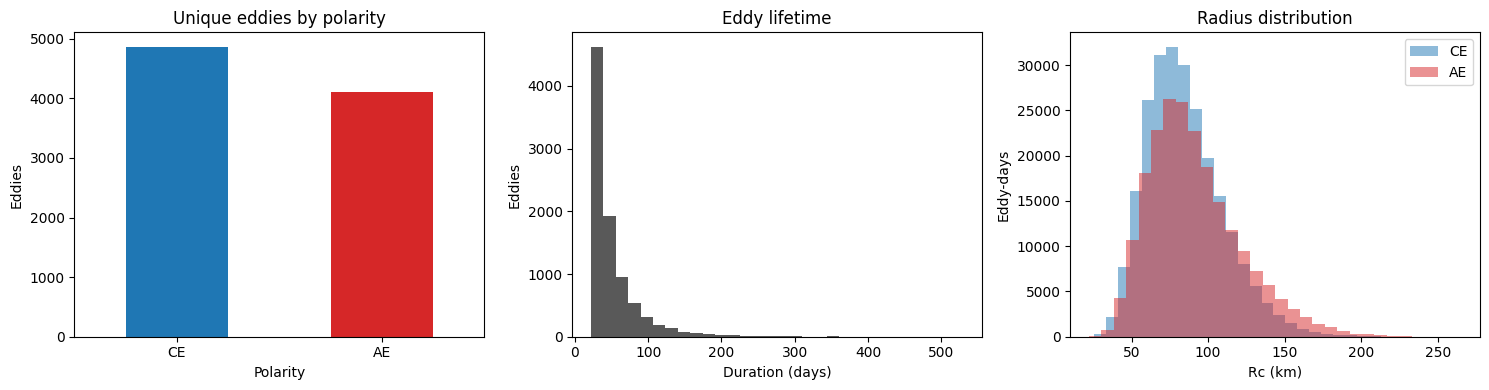

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

eddy_summary.groupby("Cyc").size().reindex(["CE", "AE"]).plot.bar(
    ax=axes[0], color=["tab:blue", "tab:red"]
)
axes[0].set(title="Unique eddies by polarity", xlabel="Polarity", ylabel="Eddies")
axes[0].tick_params(axis="x", rotation=0)

eddy_summary["duration_days"].plot.hist(ax=axes[1], bins=30, color="0.35")
axes[1].set(title="Eddy lifetime", xlabel="Duration (days)", ylabel="Eddies")

for polarity, color in [("CE", "tab:blue"), ("AE", "tab:red")]:
    df.loc[df["Cyc"].eq(polarity), "Rc"].dropna().plot.hist(
        ax=axes[2], bins=30, alpha=0.5, label=polarity, color=color
    )
axes[2].set(title="Radius distribution", xlabel="Rc (km)", ylabel="Eddy-days")
axes[2].legend()

fig.tight_layout()

## Spatial coverage

Plot one mean position per tracked eddy to keep the figure lightweight.

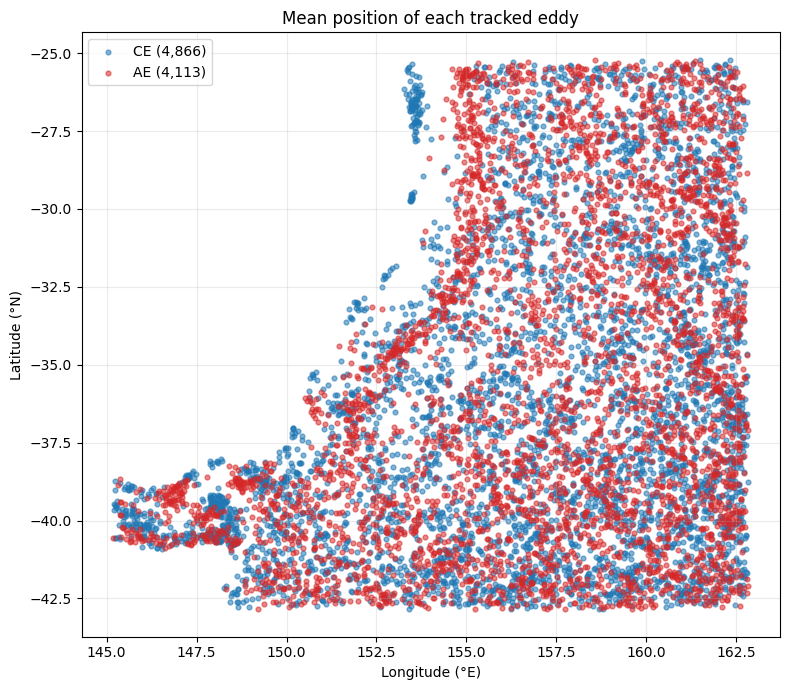

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
for polarity, color in [("CE", "tab:blue"), ("AE", "tab:red")]:
    subset = eddy_summary.loc[eddy_summary["Cyc"].eq(polarity)]
    ax.scatter(
        subset["mean_lon"], subset["mean_lat"],
        s=12, alpha=0.55, color=color, label=f"{polarity} ({len(subset):,})"
    )
ax.set(
    title="Mean position of each tracked eddy",
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

## Temporal coverage

/scratch/pbs.9246050.kman.restech.unsw.edu.au/ipykernel_3960514/1434054715.py:5: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()


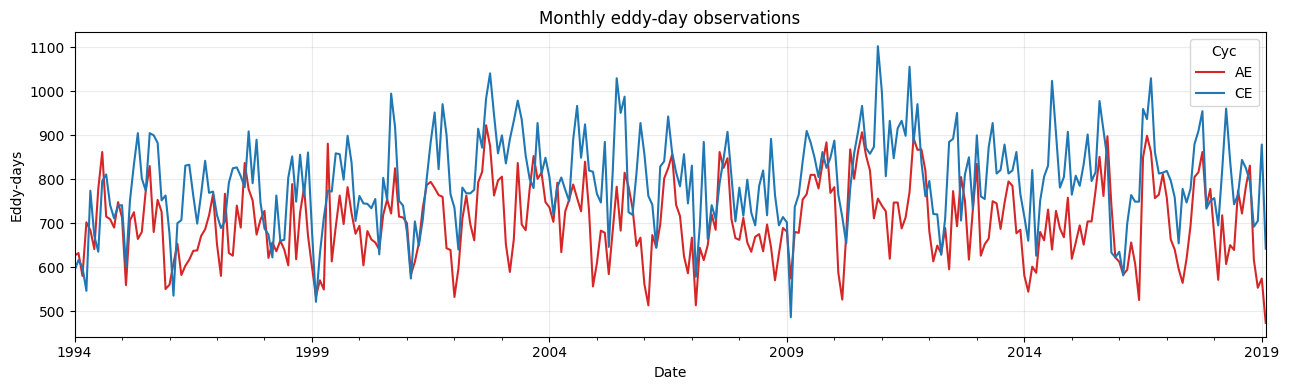

In [7]:
monthly = (
    df.set_index("Date")
    .groupby("Cyc")
    .resample("MS")
    .size()
    .unstack(0, fill_value=0)
)
ax = monthly.plot(figsize=(13, 4), color={"CE": "tab:blue", "AE": "tab:red"})
ax.set(title="Monthly eddy-day observations", xlabel="Date", ylabel="Eddy-days")
ax.grid(alpha=0.25)
plt.tight_layout()

## Inspect an individual eddy

Change `EDDY_ID` to inspect its track and fitted properties.

In [8]:
EDDY_ID = int(eddy_summary.sort_values("duration_days", ascending=False).iloc[0]["Eddy"])
eddy = df.loc[df["Eddy"].eq(EDDY_ID)].sort_values("Date")
print(f"Eddy {EDDY_ID}: {eddy.Cyc.iloc[0]}, {len(eddy)} days")
eddy.head()

Eddy 3506: CE, 530 days


,Eddy,Day,Date,Cyc,lon,lat,ic,jc,xc,yc,...,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,source_file
174978,3506,19641,2003-10-11,CE,150.889441,-38.413847,47,36,535.974795,501.901892,...,-0.000013,0.683031,0.036487,1.467990,50.853851,23.592396,1.468690,34.837545,530,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
174979,3506,19642,2003-10-12,CE,150.932312,-38.400533,47,36,539.918149,503.379177,...,-0.000018,0.685425,0.016442,1.461872,50.853851,23.592396,1.460954,31.862933,530,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
174980,3506,19643,2003-10-13,CE,150.968829,-38.393248,47,36,543.277108,504.187448,...,-0.000019,0.685267,-0.012798,1.460234,56.339128,28.079671,1.460091,28.534411,530,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
174981,3506,19644,2003-10-14,CE,151.003918,-38.392645,48,36,546.504671,504.254267,...,-0.000019,0.654169,0.025276,1.542233,61.824405,32.566947,1.536632,28.742254,530,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...
174982,3506,19645,2003-10-15,CE,151.024993,-38.404571,48,36,548.443225,502.931106,...,-0.000016,0.605506,0.103698,1.698942,67.309683,37.054222,1.693544,42.809909,530,/srv/scratch/z5502183/AVISO_0.125/AVISO_0.125_...


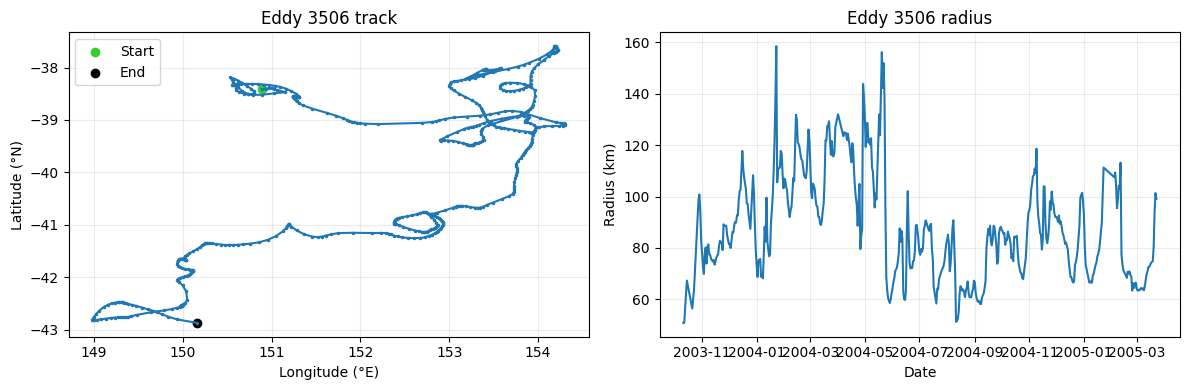

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(eddy["lon"], eddy["lat"], marker=".", ms=3)
axes[0].scatter(eddy["lon"].iloc[0], eddy["lat"].iloc[0], color="limegreen", label="Start")
axes[0].scatter(eddy["lon"].iloc[-1], eddy["lat"].iloc[-1], color="black", label="End")
axes[0].set(title=f"Eddy {EDDY_ID} track", xlabel="Longitude (°E)", ylabel="Latitude (°N)")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(eddy["Date"], eddy["Rc"], label="Rc (km)")
axes[1].set(title=f"Eddy {EDDY_ID} radius", xlabel="Date", ylabel="Radius (km)")
axes[1].grid(alpha=0.25)
fig.tight_layout()

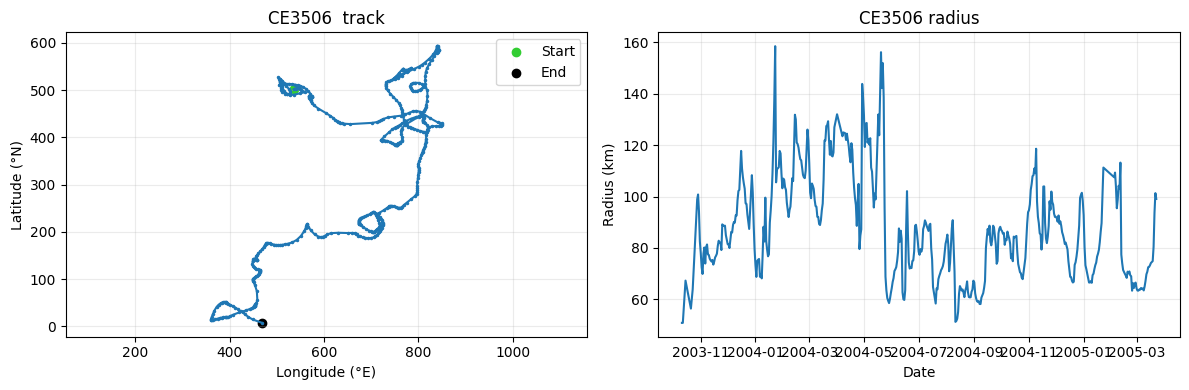

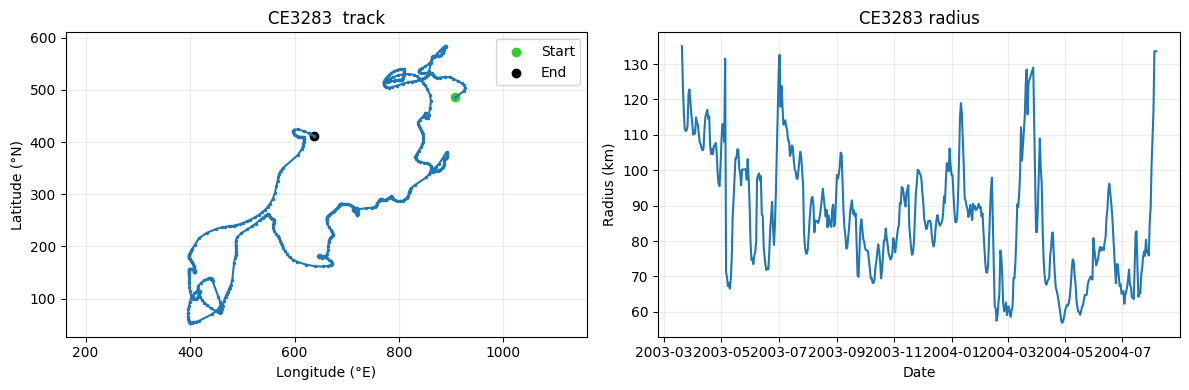

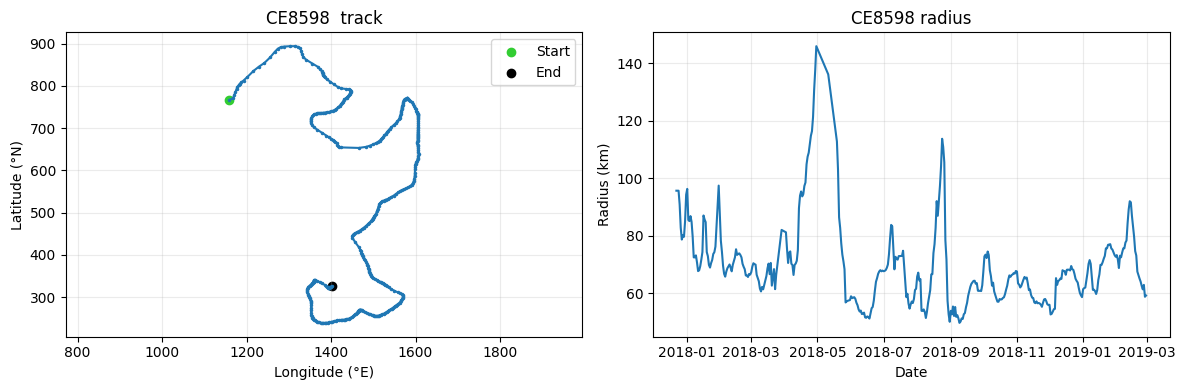

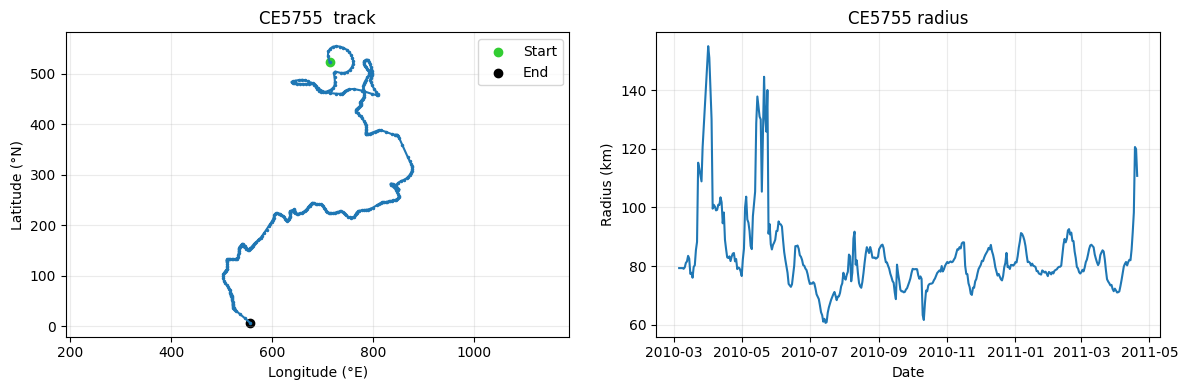

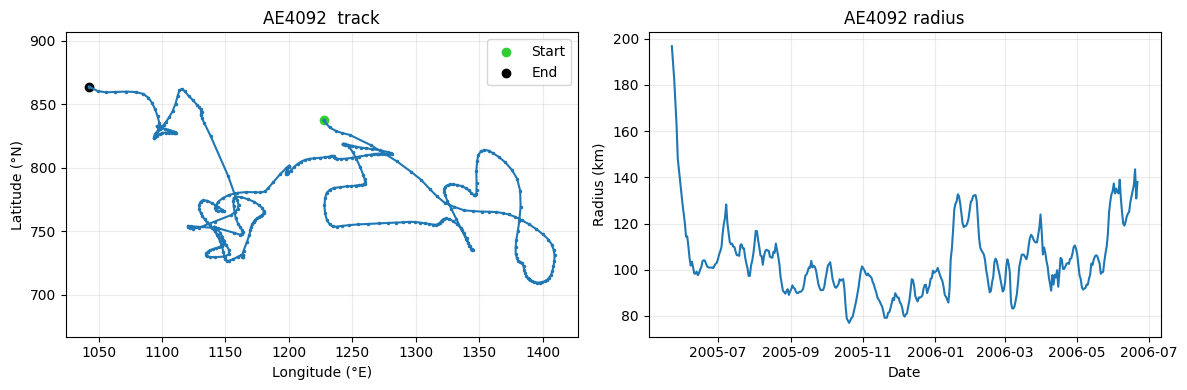

In [10]:
for k in range(5):
    EDDY_ID_k = int(eddy_summary.sort_values("duration_days", ascending=False).iloc[k]["Eddy"])
    eddy_k = df.loc[df["Eddy"].eq(EDDY_ID_k)].sort_values("Date")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(eddy_k["xc"], eddy_k["yc"], marker=".", ms=3)
    axes[0].scatter(eddy_k["xc"].iloc[0], eddy_k["yc"].iloc[0], color="limegreen", label="Start")
    axes[0].scatter(eddy_k["xc"].iloc[-1], eddy_k["yc"].iloc[-1], color="black", label="End")
    axes[0].set(title=f"{eddy_k.iloc[0].Cyc}{EDDY_ID_k}  track", xlabel="Longitude (°E)", ylabel="Latitude (°N)")
    axes[0].legend(); axes[0].grid(alpha=0.25); axes[0].axis('equal')
    
    axes[1].plot(eddy_k["Date"], eddy_k["Rc"], label="Rc (km)")
    axes[1].set(title=f"{eddy_k.iloc[0].Cyc}{EDDY_ID_k} radius", xlabel="Date", ylabel="Radius (km)")
    axes[1].grid(alpha=0.25);
    fig.tight_layout()

#### General plots

In [14]:
import sys
TILT_ROOT = Path("~/UNSW-PhD/seacofs_eddy_tilt_analysis").expanduser()
if str(TILT_ROOT) not in sys.path:
    sys.path.insert(0, str(TILT_ROOT))
import seacofs_tilt_tools as tilt

import sys
AT_ROOT = Path("~/UNSW-PhD/seacofs_eddy_dataset_modular/notebooks/").expanduser()
if str(AT_ROOT) not in sys.path:
    sys.path.insert(0, str(AT_ROOT))
import analysis_tools as at

In [16]:
df_eddies = df.copy()

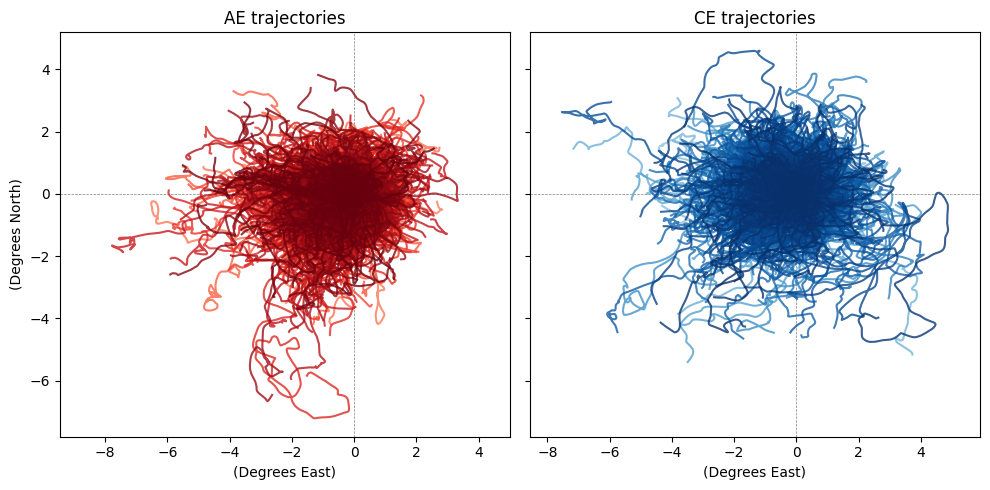

In [17]:
fig, axs = at.eddy_trajectories(df_eddies.copy())

In [19]:
dt = df_eddies.groupby('Eddy')['Day'].diff()
df_eddies['prop_x'] = df_eddies.groupby('Eddy')['xc'].diff() / dt
df_eddies['prop_y'] = df_eddies.groupby('Eddy')['yc'].diff() / dt
df_eddies['prop_dis'] = np.hypot(
    df_eddies['prop_x'],
    df_eddies['prop_y']
)
# Bearing: 0° = North, 90° = East
df_eddies['prop_dir'] = np.degrees(
        np.arctan2(
            df_eddies['prop_x'],
            df_eddies['prop_y']
        ))


<function matplotlib.pyplot.suptitle(t: 'str', **kwargs) -> 'Text'>

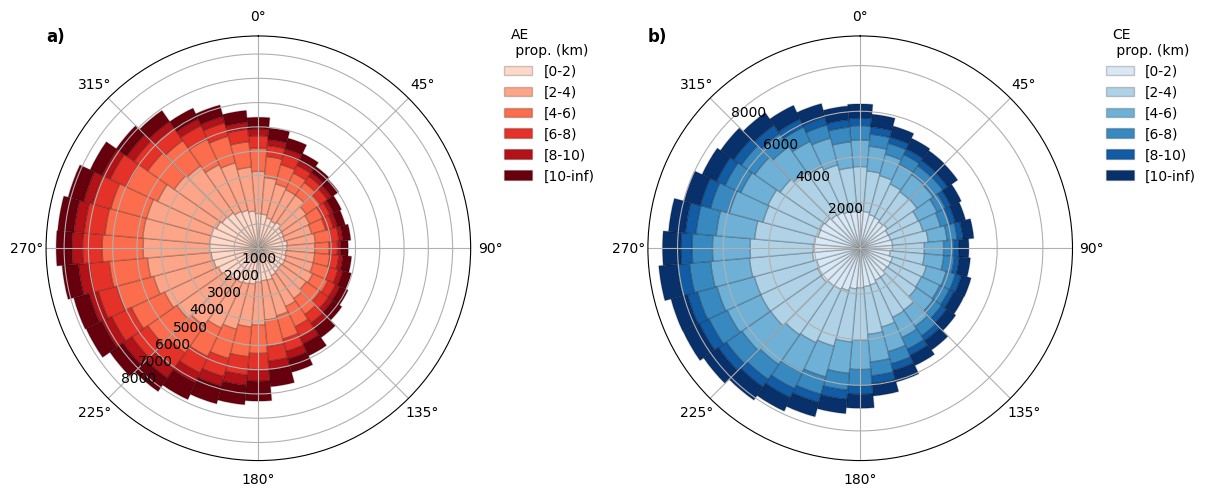

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 2, 4, 6, 8, 10, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["prop_dir", "prop_dis"])
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='prop_dis', theta='prop_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n prop. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle

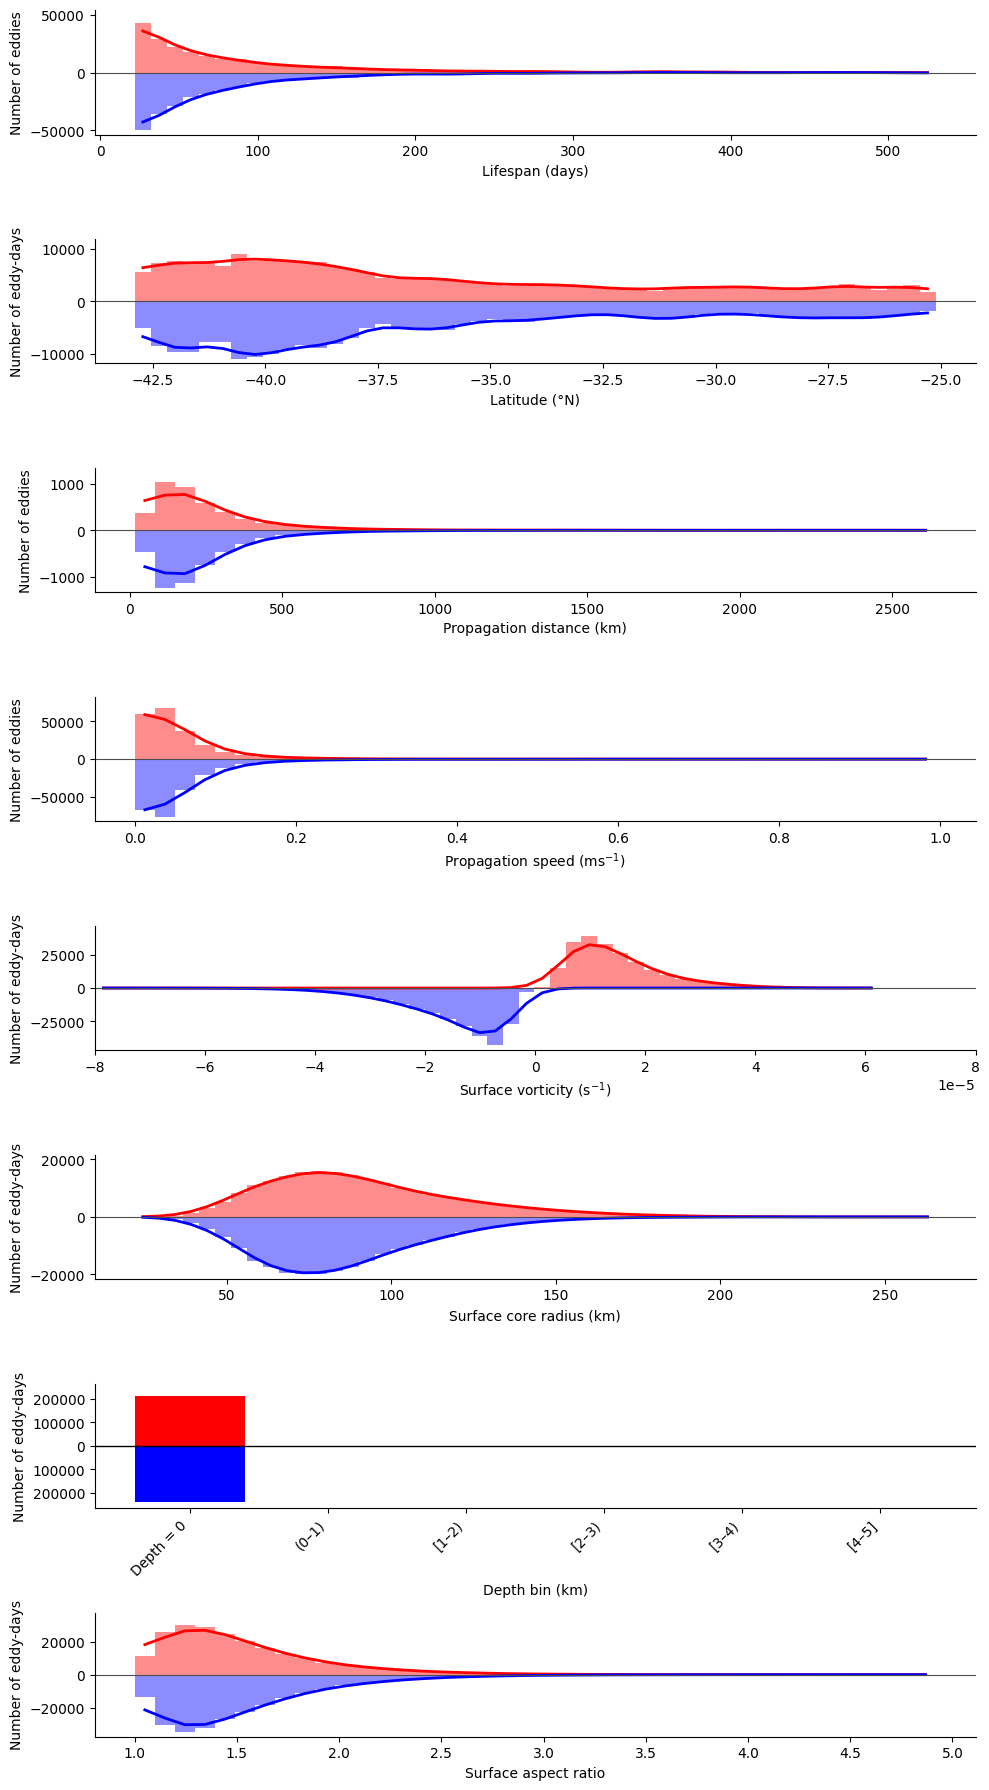

In [24]:
df_eddies["max_profile_depth"] = 0
df_eddies["EddyProp"] = 0
fig, axs = at.summary_plot(df_eddies.copy())